In [40]:
import sys
import os
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))

In [41]:
from src.features.feature_pipeline import build_feature_matrix
from src.utils.io import load_raw_data

In [42]:
datasets = load_raw_data()

In [43]:
device_catalog = datasets["device_catalog"]
device_sessions = datasets["device_sessions"]
dts_holdout = datasets["dts_holdout"]
dts_train = datasets["dts_train"]
kyc_records = datasets["kyc_records"]
sim_events = datasets["sim_events"]

In [44]:
holdout_features = build_feature_matrix(
    customer_df=dts_holdout,
    sim_events=sim_events,
    device_sessions=device_sessions,
    kyc_records=kyc_records,
    device_catalog=device_catalog,
)

In [45]:
holdout_features.shape

(20000, 119)

In [46]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

holdout_features.to_parquet(
    OUTPUT_DIR / "holdout_features.parquet",
    index=False,
)

In [47]:
holdout_features.head()

,CustomerID,kyc_level_ord,has_face_score,has_iddoc_score,face_match_score,id_doc_match_score,phone_number_age_days,sim_swap_count_total,sim_swap_count_90d,sim_swap_count_12m,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000006,1,0,1,0.000,0.896,1702,0,0,0,...,0,5,No,1,150,No,5-Low,Other,Other,No
1,3000018,2,1,1,0.855,0.869,1732,1,0,1,...,0,6,No,2,80,No,1-Highest,Other,Professional,No
2,3000034,2,1,1,0.721,0.864,1672,2,0,2,...,0,4,No,3,10,No,3-Good,Suburban,Crafts,Yes
3,3000070,2,1,1,0.972,0.989,1793,0,0,0,...,0,4,No,1,200,No,1-Highest,Other,Other,No
4,3000074,2,1,1,1.000,0.985,1580,0,0,0,...,0,3,No,0,10,No,1-Highest,Suburban,Other,No


In [48]:
holdout_features.isna().mean().sort_values(
    ascending=False
).head(20)

AgeHH1                   0.01675
AgeHH2                   0.01675
PercChangeMinutes        0.00675
PercChangeRevenues       0.00675
MonthlyRevenue           0.00300
MonthlyMinutes           0.00300
TotalRecurringCharge     0.00300
DirectorAssistedCalls    0.00300
OverageMinutes           0.00300
RoamingCalls             0.00300
ServiceArea              0.00020
PeakCallsInOut           0.00000
ActiveSubs               0.00000
UniqueSubs               0.00000
MonthsInService          0.00000
CallWaitingCalls         0.00000
CallForwardingCalls      0.00000
DroppedBlockedCalls      0.00000
OffPeakCallsInOut        0.00000
CustomerID               0.00000
dtype: float64

In [49]:
from src.utils.preprocessing import (
    preprocess_unsupervised_holdout
)

X_holdout_processed, preprocessor, X_holdout = preprocess_unsupervised_holdout(holdout_features)

In [50]:
X_holdout_processed.shape

(20000, 824)

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

from src.models.anomaly import run_isolation_forest

In [52]:
lof_candidate_cols = [
    # Device
    "shared_imei_flag",
    "high_shared_imei_flag",
    "max_customers_per_imei",
    "is_rooted",
    "rooted_session_ratio",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "emulator_session_ratio",
    "tac_risk_score",
    "tac_customer_count_max",
    "tac_imei_count_max",
    "observed_device_days",
    "low_tier_session_ratio",
    "low_tier_device_flag",
    "device_catalog_missing_ratio",
    "device_catalog_missing_any",
    "tac_grey_clone_flag",

    # SIM
    "phone_number_age_days",
    "sim_swap_count_total",
    "sim_swap_count_90d",
    "sim_swap_count_12m",
    "days_since_last_sim_swap",
    "iccid_count",
    "port_in_flag",
    "recent_sim_change_flag",

    # Behavior
    "distinct_ip_count",
    "distinct_country_count",
    "datacenter_ratio",
    "vpn_proxy_ratio",
    "non_residential_ratio",
    "home_cell_ratio",
    "night_session_ratio",
    "active_days_90d",
    "avg_sessions_per_active_day",
    "geo_velocity_flag",
    "geo_velocity_alerts_90d",
    "distinct_ip_30d",
    "distinct_country_30d",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "home_cell_ratio_30d",
    "night_session_ratio_30d",
    "active_days_30d",
    "avg_sessions_per_active_day_30d",
    "geo_velocity_flag_30d",
    "geo_velocity_alerts_30d",

    # Identity
    "kyc_level_ord",
    "has_face_score",
    "has_iddoc_score",
]

excluded_lof_cols = {
    "CustomerID",
    "FraudFlag",
    "FraudType",
    "Churn",
}

lof_feature_cols = [
    col for col in lof_candidate_cols
    if col in holdout_features.columns
    and col not in excluded_lof_cols
    and pd.api.types.is_numeric_dtype(holdout_features[col])
]

X_lof_raw = holdout_features[lof_feature_cols].copy()

lof_imputer = SimpleImputer(strategy="median")
X_lof_imputed = pd.DataFrame(
    lof_imputer.fit_transform(X_lof_raw),
    columns=lof_feature_cols,
    index=holdout_features.index,
)

lof_count_like_cols = [
    col for col in lof_feature_cols
    if any(token in col for token in ["count", "distinct", "alerts", "sessions"])
]
lof_long_day_cols = [
    col for col in ["days_since_last_sim_swap", "phone_number_age_days"]
    if col in lof_feature_cols
]

X_lof_transformed = X_lof_imputed.copy()
for col in lof_long_day_cols:
    X_lof_transformed[col] = X_lof_transformed[col].clip(
        upper=X_lof_transformed[col].quantile(0.99)
    )

for col in sorted(set(lof_count_like_cols + lof_long_day_cols)):
    X_lof_transformed[col] = X_lof_transformed[col].clip(lower=0)
    X_lof_transformed[col] = np.log1p(X_lof_transformed[col])

lof_scaler = RobustScaler()
X_lof_processed = lof_scaler.fit_transform(X_lof_transformed)

In [53]:
rows = []

for c in [0.03, 0.04, 0.05]:
    iso_result = run_isolation_forest(
        X_holdout_processed,
        contamination=c,
        n_estimators=500,
        random_state=42,
    )
    iso_score = iso_result["score"]

    for k in [50, 100, 200]:
        lof = LocalOutlierFactor(
            n_neighbors=k,
            contamination=c,
            n_jobs=-1,
        )
        lof.fit_predict(X_lof_processed)
        lof_score = -lof.negative_outlier_factor_

        top_n = int(len(holdout_features) * c)

        iso_top = set(
            pd.Series(iso_score)
            .nlargest(top_n)
            .index
        )

        lof_top = set(
            pd.Series(lof_score)
            .nlargest(top_n)
            .index
        )

        overlap = len(iso_top & lof_top)

        rows.append(
            {
                "contamination": c,
                "lof_n_neighbors": k,
                "top_n": top_n,
                "overlap": overlap,
                "overlap_ratio": overlap / top_n,
            }
        )

overlap_results = pd.DataFrame(rows)

overlap_results.sort_values(
    ["contamination", "overlap_ratio"],
    ascending=[True, False]
)

,contamination,lof_n_neighbors,top_n,overlap,overlap_ratio
2,0.03,200,600,134,0.223333
1,0.03,100,600,107,0.178333
0,0.03,50,600,85,0.141667
5,0.04,200,800,194,0.242500
4,0.04,100,800,157,0.196250
3,0.04,50,800,139,0.173750
8,0.05,200,1000,236,0.236000
7,0.05,100,1000,206,0.206000
6,0.05,50,1000,184,0.184000


In [54]:
CONTAMINATION = 0.04

iso_result = run_isolation_forest(
    X_holdout_processed,
    contamination=CONTAMINATION,
    n_estimators=500,
    random_state=42,
)

lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=CONTAMINATION,
    n_jobs=-1,
)
lof.fit_predict(X_lof_processed)

array([ 1,  1, -1, ...,  1,  1,  1], shape=(20000,))

In [55]:
iso_score = iso_result["score"]
lof_score = -lof.negative_outlier_factor_

In [56]:
scores = pd.DataFrame({
    "iso": iso_score,
    "lof": lof_score,
})

scores.corr(
    method="spearman"
)

,iso,lof
iso,1.000000,0.369485
lof,0.369485,1.000000


In [57]:
top_n = int(len(holdout_features) * CONTAMINATION)

iso_top = set(
    pd.Series(iso_score)
    .nlargest(top_n)
    .index
)

lof_top = set(
    pd.Series(lof_score)
    .nlargest(top_n)
    .index
)

overlap = len(iso_top & lof_top)
overlap_ratio = overlap / top_n

overlap, overlap_ratio

(139, 0.17375)

In [58]:
both_idx = list(iso_top & lof_top)

both_cases = holdout_features.iloc[both_idx]

iso_only_idx = list(iso_top - lof_top)

iso_only_cases = holdout_features.iloc[iso_only_idx]

lof_only_idx = list(lof_top - iso_top)

lof_only_cases = holdout_features.iloc[lof_only_idx]

risk_features = [
    # Device
    "shared_imei_flag",
    "high_shared_imei_flag",
    "max_customers_per_imei",
    "is_rooted",
    "rooted_session_ratio",
    "is_emulator",
    "is_generic_or_clone",
    "is_feature_phone",
    "tac_risk_score",

    # SIM
    "sim_swap_count_90d",
    "days_since_last_sim_swap",

    # Behavior
    "distinct_ip_30d",
    "distinct_country_30d",
    "datacenter_ratio_30d",
    "vpn_proxy_ratio_30d",
    "non_residential_ratio_30d",
    "night_session_ratio_30d",
    "geo_velocity_alerts_30d",

    # Identity
    "kyc_level_ord",
    "has_face_score",
    "has_iddoc_score",
]

comparison = pd.DataFrame({
    "population": holdout_features[risk_features].mean(),
    "iso_only": iso_only_cases[risk_features].mean(),
    "lof_only": lof_only_cases[risk_features].mean(),
    "both": both_cases[risk_features].mean(),
})

comparison["iso_lift"] = (
    comparison["iso_only"]
    /
    comparison["population"].replace(0, pd.NA)
)

comparison["lof_lift"] = (
    comparison["lof_only"]
    /
    comparison["population"].replace(0, pd.NA)
)

comparison["both_lift"] = (
    comparison["both"]
    /
    comparison["population"].replace(0, pd.NA)
)

comparison.sort_values(
    "both_lift",
    ascending=False
)

,population,iso_only,lof_only,both,iso_lift,lof_lift,both_lift
high_shared_imei_flag,0.007450,0.095310,0.021180,0.187050,12.793307,2.842957,25.107431
is_rooted,0.023500,0.098336,0.236006,0.266187,4.184504,10.042811,11.327109
rooted_session_ratio,0.023500,0.098336,0.236006,0.266187,4.184504,10.042811,11.327109
vpn_proxy_ratio_30d,0.009715,0.047660,0.020151,0.104607,4.905600,2.074156,10.767168
non_residential_ratio_30d,0.023972,0.112702,0.058851,0.254428,4.701368,2.454958,10.613484
datacenter_ratio_30d,0.014257,0.065042,0.038699,0.149820,4.562192,2.714461,10.508755
geo_velocity_alerts_30d,0.031450,0.276853,0.075643,0.273381,8.802965,2.405182,8.692569
shared_imei_flag,0.052400,0.158850,0.287443,0.438849,3.031493,5.485559,8.374979
is_feature_phone,0.093550,0.158850,0.083207,0.237410,1.698025,0.889442,2.537788
sim_swap_count_90d,0.073650,0.133132,0.130106,0.151079,1.807626,1.766543,2.051312


In [59]:
anomaly_result = holdout_features[["CustomerID"]].copy()

assert len(holdout_features) == len(anomaly_result)
assert holdout_features["CustomerID"].is_unique
assert anomaly_result["CustomerID"].is_unique
assert holdout_features["CustomerID"].reset_index(drop=True).equals(
    anomaly_result["CustomerID"].reset_index(drop=True)
)

anomaly_result["iso_score"] = iso_result["score"]
anomaly_result["lof_score"] = -lof.negative_outlier_factor_

anomaly_result["iso_rank_pct"] = anomaly_result["iso_score"].rank(pct=True)
anomaly_result["lof_rank_pct"] = anomaly_result["lof_score"].rank(pct=True)

anomaly_result["anomaly_score"] = (
    0.90 * anomaly_result["iso_rank_pct"]
    + 0.10 * anomaly_result["lof_rank_pct"]
)

In [60]:
anomaly_result.sort_values(
    "anomaly_score",
    ascending=False
).head(20)

,CustomerID,iso_score,lof_score,iso_rank_pct,lof_rank_pct,anomaly_score
2593,3052314,0.482393,1.476469,0.99995,0.99190,0.999145
376,3007294,0.459946,1.546196,0.99925,0.99655,0.998980
4256,3086598,0.462148,1.456411,0.99950,0.98885,0.998435
920,3018358,0.452166,1.630401,0.99830,0.99900,0.998370
18735,3376618,0.449917,1.635808,0.99800,0.99910,0.998110
1170,3023606,0.451510,1.467781,0.99815,0.99075,0.997410
1795,3035974,0.453272,1.422606,0.99840,0.98205,0.996765
570,3011370,0.457056,1.395735,0.99895,0.97520,0.996575
584,3011570,0.482608,1.365285,1.00000,0.96450,0.996450
5808,3117494,0.448423,1.429836,0.99765,0.98400,0.996285


In [61]:
anomaly_result.to_csv(
    "../outputs/anomaly_scores.csv",
    index=False
)

## Graph

In [62]:
from src.graph.customer_graph import (
    build_customer_graph_edges,
    build_networkx_customer_graph,
    get_customer_neighbors,
    get_ego_graph,
)

In [63]:
holdout_customer_ids = holdout_features["CustomerID"].unique()

edge_df = build_customer_graph_edges(
    device_sessions=device_sessions,
    sim_events=sim_events,
    customer_ids=holdout_customer_ids,
)

strong_relation_pattern = (
    "shared_imei"
    "|shared_iccid"
    "|shared_risky_ip_same_day"
    "|shared_risky_ip"
)

edge_df_score = edge_df[
    edge_df["relations"].str.contains(
        strong_relation_pattern,
        regex=True,
        na=False,
    )
].copy()

G = build_networkx_customer_graph(edge_df_score)

edge_df_score.shape, G.number_of_nodes(), G.number_of_edges()

((3089, 9), 1918, 3089)

In [64]:
edge_df.to_csv("../outputs/customer_graph_edges_holdout.csv", index=False)
edge_df_score.to_csv("../outputs/customer_graph_edges_holdout_strong.csv", index=False)

In [65]:
neighbors = get_customer_neighbors(edge_df, 3035234)
neighbors.head(20)

,customer_a,customer_b,total_edge_weight,max_edge_weight,relation_count,evidence_count,max_entity_customer_count,relations,evidence_examples,neighbor_customer
137,3035234,3303734,13.0,4.0,2,4,9,shared_risky_ip|shared_risky_ip_same_day,103.142.74.230|45.129.57.201|45.142.74.230|45....,3303734
516,3035234,3199090,9.0,3.0,1,3,9,shared_risky_ip,103.129.57.201|103.142.74.230|45.129.57.201,3199090
517,3035234,3203922,9.0,3.0,1,3,9,shared_risky_ip,103.142.74.230|45.129.57.201|45.142.74.230,3203922
518,3035234,3323510,9.0,3.0,1,3,9,shared_risky_ip,103.129.57.201|103.142.74.230|45.129.57.201,3323510
1063,3035234,3122834,6.0,3.0,1,2,9,shared_risky_ip,103.142.74.230|45.142.74.230,3122834
1064,3035234,3209594,6.0,3.0,1,2,9,shared_risky_ip,103.142.74.230|45.142.74.230,3209594
1065,3035234,3333590,6.0,3.0,1,2,9,shared_risky_ip,103.142.74.230|45.129.57.201,3333590
1066,3035234,3386302,6.0,3.0,1,2,9,shared_risky_ip,103.129.57.201|103.142.74.230,3386302
1685,3027930,3035234,5.0,5.0,1,1,8,shared_imei,352011057403512,3027930
1718,3035234,3096614,5.0,5.0,1,1,8,shared_imei,352011057403512,3096614


In [66]:
score_map = (
    anomaly_result
    .set_index("CustomerID")["anomaly_score"]
    .to_dict()
)

for node in G.nodes:
    G.nodes[node]["anomaly_score"] = score_map.get(node, 0)

In [67]:
def neighbor_anomaly_summary(G, customer_id):
    if customer_id not in G:
        return {
            "CustomerID": customer_id,
            "neighbor_count": 0,
            "neighbor_anomaly_max": 0,
            "neighbor_anomaly_mean": 0,
        }

    neighbors = list(G.neighbors(customer_id))

    if len(neighbors) == 0:
        return {
            "CustomerID": customer_id,
            "neighbor_count": 0,
            "neighbor_anomaly_max": 0,
            "neighbor_anomaly_mean": 0,
        }

    scores = [
        G.nodes[n].get("anomaly_score", 0)
        for n in neighbors
    ]

    return {
        "CustomerID": customer_id,
        "neighbor_count": len(neighbors),
        "neighbor_anomaly_max": max(scores),
        "neighbor_anomaly_mean": sum(scores) / len(scores),
    }

In [68]:
neighbor_risk_df = pd.DataFrame(
    [
        neighbor_anomaly_summary(G, cid)
        for cid in holdout_customer_ids
    ]
)

neighbor_risk_df.sort_values(by="neighbor_count", ascending=False).head()

,CustomerID,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean
1760,3035234,15,0.988420,0.807192
17036,3345182,14,0.992660,0.819529
4704,3095206,13,0.995255,0.880495
4948,3099530,13,0.998980,0.854541
11829,3239962,13,0.988420,0.863665


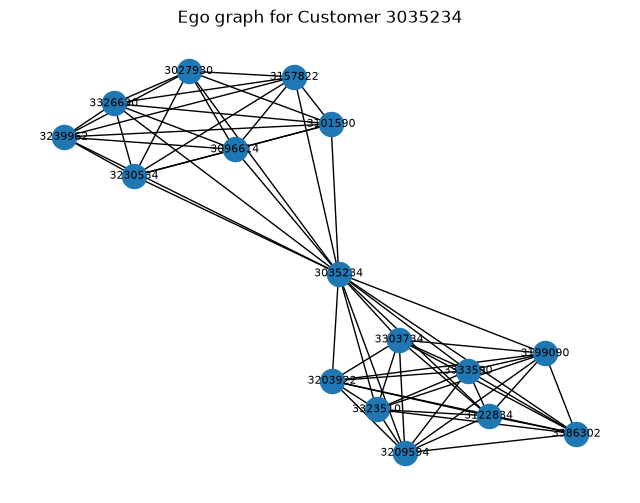

In [69]:
import matplotlib.pyplot as plt
import networkx as nx

target_customer = 3035234

ego = get_ego_graph(
    G,
    customer_id=target_customer,
    radius=1,
)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(ego, seed=42)

nx.draw_networkx_nodes(
    ego,
    pos,
    node_size=300,
)

nx.draw_networkx_edges(
    ego,
    pos,
    width=1,
)

nx.draw_networkx_labels(
    ego,
    pos,
    font_size=8,
)

plt.title(f"Ego graph for Customer {target_customer}")
plt.axis("off")
plt.show()

In [70]:
graph_result = anomaly_result.merge(
    neighbor_risk_df,
    on="CustomerID",
    how="left",
)

graph_result[[
    "neighbor_count",
    "neighbor_anomaly_max",
    "neighbor_anomaly_mean",
]] = graph_result[[
    "neighbor_count",
    "neighbor_anomaly_max",
    "neighbor_anomaly_mean",
]].fillna(0)

graph_result["neighbor_anomaly_rank_pct"] = (
    graph_result["neighbor_anomaly_max"].rank(pct=True)
)

graph_weight = 0.10
graph_result["graph_adjusted_anomaly_score"] = (
    0.90 * graph_result["anomaly_score"].rank(pct=True)
    + graph_weight * graph_result["neighbor_anomaly_rank_pct"]
)

In [71]:
graph_result.head()

,CustomerID,iso_score,lof_score,iso_rank_pct,lof_rank_pct,anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean,neighbor_anomaly_rank_pct,graph_adjusted_anomaly_score
0,3000006,0.407132,1.318483,0.94540,0.94140,0.945000,0,0.000000,0.000000,0.452075,0.914292
1,3000018,0.376874,1.056271,0.66500,0.43295,0.641795,0,0.000000,0.000000,0.452075,0.634032
2,3000034,0.440830,1.361052,0.99550,0.96280,0.992230,2,0.967645,0.771803,0.975750,0.995910
3,3000070,0.428637,1.193715,0.98855,0.81195,0.970890,0,0.000000,0.000000,0.452075,0.933148
4,3000074,0.369401,1.085959,0.53365,0.54855,0.535140,0,0.000000,0.000000,0.452075,0.530037


In [72]:
graph_result.to_csv("../outputs/anomaly_graph_score.csv", index=False)

In [73]:
graph_result.sort_values("neighbor_count", ascending=False).head(20)

,CustomerID,iso_score,lof_score,iso_rank_pct,lof_rank_pct,anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean,neighbor_anomaly_rank_pct,graph_adjusted_anomaly_score
1760,3035234,0.452166,1.168666,0.99825,0.76600,0.975025,15,0.988420,0.807192,0.989825,0.989577
17036,3345182,0.409075,1.060133,0.95240,0.45145,0.902305,14,0.992660,0.819529,0.995100,0.932595
4704,3095206,0.419055,1.079903,0.97670,0.52655,0.931685,13,0.995255,0.880495,0.997475,0.958888
4948,3099530,0.461633,1.146680,0.99940,0.71825,0.971285,13,0.998980,0.854541,0.999450,0.988200
11829,3239962,0.430240,1.260089,0.98990,0.89755,0.980665,13,0.988420,0.863665,0.989825,0.992637
9210,3185570,0.421779,1.072894,0.98150,0.50140,0.933490,13,0.957420,0.788622,0.970775,0.957477
11419,3230534,0.421976,1.179932,0.98175,0.78855,0.962430,13,0.988420,0.921867,0.989825,0.981117
7528,3152282,0.436666,1.103697,0.99410,0.60520,0.955210,13,0.984790,0.862762,0.987300,0.976005
16147,3326630,0.423781,1.161145,0.98400,0.74980,0.960580,13,0.988420,0.865210,0.989825,0.979633
745,3014690,0.464928,1.145455,0.99955,0.71505,0.971100,12,0.995100,0.784328,0.996600,0.987712


In [74]:
# Overlap với base
top_n = int(len(graph_result) * 0.04)

top_base = set(
    graph_result.nlargest(top_n, "anomaly_score")["CustomerID"]
)

top_graph = set(
    graph_result.nlargest(top_n, "graph_adjusted_anomaly_score")["CustomerID"]
)

overlap = len(top_base & top_graph) / top_n
overlap

0.73375

In [75]:
top_n = int(len(graph_result) * 0.04)

top_base = set(
    graph_result.nlargest(top_n, "anomaly_score")["CustomerID"]
)

top_graph = set(
    graph_result.nlargest(top_n, "graph_adjusted_anomaly_score")["CustomerID"]
)

new_by_graph = top_graph - top_base

len(new_by_graph), len(new_by_graph) / top_n

(213, 0.26625)

In [76]:
new_by_graph_df = graph_result[
    graph_result["CustomerID"].isin(new_by_graph)
].copy()

new_by_graph_df[
    [
        "CustomerID",
        "anomaly_score",
        "graph_adjusted_anomaly_score",
        "neighbor_count",
        "neighbor_anomaly_max",
        "neighbor_anomaly_mean",
        "neighbor_anomaly_rank_pct",
    ]
].sort_values("graph_adjusted_anomaly_score", ascending=False).head(30)

,CustomerID,anomaly_score,graph_adjusted_anomaly_score,neighbor_count,neighbor_anomaly_max,neighbor_anomaly_mean,neighbor_anomaly_rank_pct
17833,3360478,0.937815,0.963577,5,0.999145,0.775039,0.999825
8840,3177934,0.938160,0.962808,5,0.987790,0.776433,0.989425
5683,3114750,0.935485,0.961583,7,0.995150,0.762261,0.996975
8483,3170846,0.936625,0.961390,3,0.985145,0.922867,0.987850
14718,3298954,0.935920,0.960193,2,0.974460,0.787173,0.981275
18340,3369814,0.936165,0.959795,4,0.965950,0.648121,0.975050
14647,3297714,0.934155,0.959495,3,0.983420,0.788762,0.986450
4704,3095206,0.931685,0.958888,13,0.995255,0.880495,0.997475
161,3003542,0.936315,0.957935,5,0.925990,0.692066,0.955550
9210,3185570,0.933490,0.957477,13,0.957420,0.788622,0.970775


In [77]:
# Check relations
edge_new = edge_df[
    edge_df["customer_a"].isin(new_by_graph)
    | edge_df["customer_b"].isin(new_by_graph)
].copy()

edge_new["new_customer"] = edge_new.apply(
    lambda row: row["customer_a"]
    if row["customer_a"] in new_by_graph
    else row["customer_b"],
    axis=1,
)

edge_new_summary = (
    edge_new.groupby("new_customer")
    .agg(
        edge_count=("relations", "size"),
        total_edge_weight=("total_edge_weight", "sum"),
        max_edge_weight=("total_edge_weight", "max"),
        relations=("relations", lambda x: " | ".join(sorted(set(x)))),
        evidence_examples=("evidence_examples", lambda x: " | ".join(x.astype(str).head(5))),
    )
    .reset_index()
    .sort_values(["total_edge_weight", "edge_count"], ascending=False)
)

edge_new_summary.head(30)

,new_customer,edge_count,total_edge_weight,max_edge_weight,relations,evidence_examples
115,3185570,12,89.0,19.0,shared_imei | shared_risky_ip | shared_risky_i...,103.209.219.199|103.235.253.3|103.248.16.32|45...
63,3085374,7,86.0,16.0,shared_risky_ip | shared_risky_ip|shared_risky...,103.119.107.171|103.93.73.113|45.119.107.171|4...
68,3095206,12,84.0,18.0,shared_imei | shared_risky_ip,103.176.200.172|103.215.251.5|45.163.183.143|4...
84,3114750,6,83.0,20.0,shared_risky_ip | shared_risky_ip|shared_risky...,103.158.30.32|103.184.64.90|45.158.30.32|45.17...
21,3022182,7,79.0,16.0,shared_risky_ip | shared_risky_ip|shared_risky...,103.158.30.32|103.171.47.61|45.158.30.32|45.18...
182,3345182,11,68.0,12.0,shared_imei | shared_risky_ip,103.127.199.55|103.153.233.113|45.140.216.84|4...
151,3273594,7,68.0,22.0,shared_imei | shared_risky_ip | shared_risky_i...,103.131.93.189|103.144.110.218|103.183.161.51|...
148,3260706,11,64.0,15.0,shared_imei | shared_risky_ip,103.126.16.236|103.152.50.40|45.126.16.236|45....
171,3323510,7,64.0,16.0,shared_risky_ip | shared_risky_ip|shared_risky...,103.142.74.230|103.155.91.5|45.129.57.201|45.1...
9,3008246,6,62.0,16.0,shared_risky_ip | shared_risky_ip|shared_risky...,103.119.5.233|45.119.5.233|45.132.22.8|45.145....


In [78]:
relation_exploded = (
    edge_new_summary["relations"]
    .str.split(r"\s*\|\s*", expand=False)
    .explode()
    .value_counts()
)

relation_exploded

relations
shared_risky_ip                     166
shared_imei                         101
shared_risky_ip_same_day             39
shared_residential_wifi_repeated     24
Name: count, dtype: int64